In [ ]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.5 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision.models as models
import torchvision.transforms as transforms

import numpy as np
import random
import medmnist
from medmnist import INFO

import matplotlib.pyplot as plt


In [ ]:
def set_seed(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
def train(model, device, train_loader, optimizer, epoch, display=True):
    model.train()
    correct = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.binary_cross_entropy_with_logits(output, target.float())
        loss.backward()
        optimizer.step()
        pred = output >= 0.5
        correct += pred.eq(target.view_as(pred)).sum().item()
    if display:
      print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
          epoch, batch_idx * len(data), len(train_loader.dataset),
          100. * batch_idx / len(train_loader), loss.item()))
    return loss.item(), 100. * correct / len(train_loader.dataset)

def test(model, device, test_loader, name="\nVal"):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.binary_cross_entropy_with_logits(output, target.float(), reduction='sum').item() # sum up batch loss
            pred = output >= 0.5
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    return 100. * correct / len(test_loader.dataset)

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Set paths
data_path = "/content/drive/MyDrive/chest_xray/"
filenames = tf.io.gfile.glob(str(data_path+ '/train/*/*'))
filenames.extend(tf.io.gfile.glob(str(data_path + '/val/*/*')))

train_filenames, val_filenames = train_test_split(filenames, test_size=0.2)

In [ ]:
COUNT_NORMAL = len([filename for filename in train_filenames if "NORMAL" in filename])
print("Normal images count in training set: " + str(COUNT_NORMAL))

COUNT_PNEUMONIA = len([filename for filename in train_filenames if "PNEUMONIA" in filename])
print("Pneumonia images count in training set: " + str(COUNT_PNEUMONIA))

Normal images count in training set: 1075
Pneumonia images count in training set: 3110


In [ ]:
train_list_ds = tf.data.Dataset.from_tensor_slices(train_filenames)
val_list_ds = tf.data.Dataset.from_tensor_slices(val_filenames)

for f in train_list_ds.take(10):
    print(f.numpy())

b'/content/drive/MyDrive/chest_xray//train/PNEUMONIA/person1138_bacteria_3080.jpeg'
b'/content/drive/MyDrive/chest_xray//train/PNEUMONIA/person1758_bacteria_4600.jpeg'
b'/content/drive/MyDrive/chest_xray//train/PNEUMONIA/person841_bacteria_2760.jpeg'
b'/content/drive/MyDrive/chest_xray//train/PNEUMONIA/person70_bacteria_343.jpeg'
b'/content/drive/MyDrive/chest_xray//train/PNEUMONIA/person1271_bacteria_3231.jpeg'
b'/content/drive/MyDrive/chest_xray//train/NORMAL/IM-0549-0001-0001.jpeg'
b'/content/drive/MyDrive/chest_xray//train/NORMAL/IM-0403-0001.jpeg'
b'/content/drive/MyDrive/chest_xray//train/NORMAL/IM-0554-0001.jpeg'
b'/content/drive/MyDrive/chest_xray//train/PNEUMONIA/person256_bacteria_1189.jpeg'
b'/content/drive/MyDrive/chest_xray//train/PNEUMONIA/person60_bacteria_287.jpeg'


In [ ]:
TRAIN_IMG_COUNT = tf.data.experimental.cardinality(train_list_ds).numpy()
print("Training images count: " + str(TRAIN_IMG_COUNT))

VAL_IMG_COUNT = tf.data.experimental.cardinality(val_list_ds).numpy()
print("Validating images count: " + str(VAL_IMG_COUNT))

Training images count: 4185
Validating images count: 1047


In [ ]:
import os
CLASS_NAMES = np.array([str(tf.strings.split(item, os.path.sep)[-1].numpy())[2:-1]
                        for item in tf.io.gfile.glob(str(data_path + "/train/*"))])
CLASS_NAMES

array(['PNEUMONIA', 'NORMAL'], dtype='<U9')

In [ ]:
import tensorflow as tf
import os

# Define necessary variables for the TensorFlow dataset pipeline

IMAGE_SIZE = (128, 128) # Define image size
BATCH_SIZE = 32 # Define batch size
AUTOTUNE = tf.data.AUTOTUNE # Define AUTOTUNE

# List image files for training and validation
train_filenames = tf.io.gfile.glob(str(data_path + '/train/*/*'))
val_filenames = tf.io.gfile.glob(str(data_path + '/val/*/*'))

# Create TensorFlow datasets from filenames
train_list_ds = tf.data.Dataset.from_tensor_slices(train_filenames)
val_list_ds = tf.data.Dataset.from_tensor_slices(val_filenames)

for f in train_list_ds.take(10):
    print(f.numpy())

b'/content/drive/MyDrive/chest_xray//train/NORMAL/IM-0545-0001-0001.jpeg'
b'/content/drive/MyDrive/chest_xray//train/NORMAL/IM-0530-0001.jpeg'
b'/content/drive/MyDrive/chest_xray//train/NORMAL/IM-0519-0001-0002.jpeg'
b'/content/drive/MyDrive/chest_xray//train/NORMAL/IM-0503-0001.jpeg'
b'/content/drive/MyDrive/chest_xray//train/NORMAL/IM-0519-0001.jpeg'
b'/content/drive/MyDrive/chest_xray//train/NORMAL/IM-0544-0001.jpeg'
b'/content/drive/MyDrive/chest_xray//train/NORMAL/IM-0511-0001-0001.jpeg'
b'/content/drive/MyDrive/chest_xray//train/NORMAL/IM-0526-0001.jpeg'
b'/content/drive/MyDrive/chest_xray//train/NORMAL/IM-0505-0001-0001.jpeg'
b'/content/drive/MyDrive/chest_xray//train/NORMAL/IM-0529-0001.jpeg'


In [ ]:
def get_label(file_path):
    # convert the path to a list of path components
    parts = tf.strings.split(file_path, os.path.sep)
    # The second to last is the class-directory
    return parts[-2] == "PNEUMONIA"


In [ ]:
def decode_img(img):
  # convert the compressed string to a 3D uint8 tensor
  img = tf.image.decode_jpeg(img, channels=3)
  # Use `convert_image_dtype` to convert to floats in the [0,1] range.
  img = tf.image.convert_image_dtype(img, tf.float32)
  # resize the image to the desired size.
  return tf.image.resize(img, IMAGE_SIZE)

In [ ]:
def process_path(file_path):
    label = get_label(file_path)
    # load the raw data from the file as a string
    img = tf.io.read_file(file_path)
    img = decode_img(img)
    return img, label

In [ ]:
train_ds = train_list_ds.map(process_path, num_parallel_calls=AUTOTUNE)

val_ds = val_list_ds.map(process_path, num_parallel_calls=AUTOTUNE)

In [ ]:
## visualize the shape of an (image, label) pair.
for image, label in train_ds.take(1):
    print("Image shape: ", image.numpy().shape)
    print("Label: ", label.numpy())

Image shape:  (128, 128, 3)
Label:  False


In [ ]:
test_list_ds = tf.data.Dataset.list_files(str(data_path + '/test/*/*'))
TEST_IMAGE_COUNT = tf.data.experimental.cardinality(test_list_ds).numpy()
test_ds = test_list_ds.map(process_path, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)

TEST_IMAGE_COUNT

np.int64(624)

In [ ]:
def prepare_for_training(ds, cache=True, shuffle_buffer_size=1000):
    # This is a small dataset, only load it once, and keep it in memory.
    # use `.cache(filename)` to cache preprocessing work for datasets that don't
    # fit in memory.
    if cache:
        if isinstance(cache, str):
            ds = ds.cache(cache)
        else:
            ds = ds.cache()

    ds = ds.shuffle(buffer_size=shuffle_buffer_size)

    # Repeat forever
    ds = ds.repeat()

    ds = ds.batch(BATCH_SIZE)

    # `prefetch` lets the dataset fetch batches in the background while the model
    # is training.
    ds = ds.prefetch(buffer_size=AUTOTUNE)

    return ds

In [ ]:
train_ds = prepare_for_training(train_ds)
val_ds = prepare_for_training(val_ds)

image_batch, label_batch = next(iter(train_ds))


In [ ]:
def show_batch(image_batch, label_batch):
    plt.figure(figsize=(10,10))
    for n in range(25):
        ax = plt.subplot(5,5,n+1)
        plt.imshow(image_batch[n])
        if label_batch[n]:
            plt.title("PNEUMONIA")
        else:
            plt.title("NORMAL")
        plt.axis("off")

## Visualizing Images

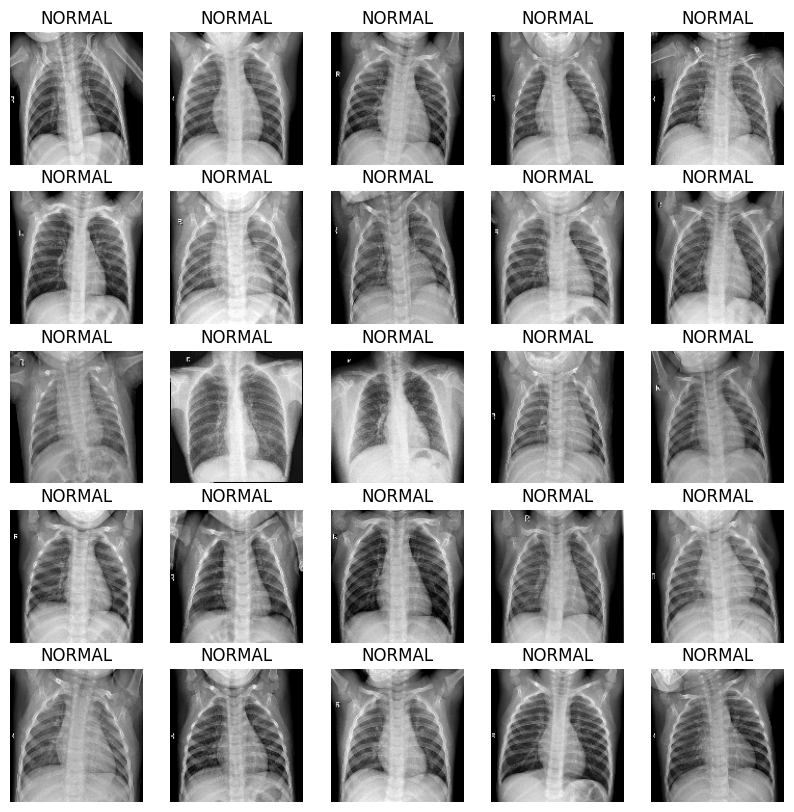

In [ ]:
show_batch(image_batch.numpy(), label_batch.numpy())

## CNN Model


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.layers = nn.ModuleList()

        self.layers+=[nn.Conv2d(1, 16,  kernel_size=3) ,
                      nn.ReLU(inplace=True)]
        self.layers+=[nn.Conv2d(16, 16,  kernel_size=3, stride=2),
                      nn.ReLU(inplace=True)]
        self.layers+=[nn.Conv2d(16, 32,  kernel_size=3),
                      nn.ReLU(inplace=True)]
        self.layers+=[nn.Conv2d(32, 32,  kernel_size=3, stride=2),
                      nn.ReLU(inplace=True)]
        self.fc = nn.Linear(32*4*4, 1)
    def forward(self, x):
        for i in range(len(self.layers)):
          x = self.layers[i](x)
        x = x.view(-1, 32*4*4)
        x = self.fc(x)
        return x

In [ ]:
%%time
from torchvision.transforms.autoaugment import RandAugment
from random import randint
from numpy.random import RandomState
from torch.utils.data import Subset # Added import for Subset

torch.manual_seed(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
random.seed(0)
np.random.seed(0)

# preprocessing
data_flag = 'pneumoniamnist'

download = True

info = INFO[data_flag]
n_classes = len(info['label'])
DataClass = getattr(medmnist, info['python_class'])

trn_transform = transforms.Compose([transforms.RandAugment(),
                                     transforms.ToTensor(),
                                     transforms.Normalize(mean=[.5], std=[.5])])

val_transform = transforms.Compose([transforms.ToTensor(),
                                     transforms.Normalize(mean=[.5], std=[.5])])

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

# load the data
train_dataset = DataClass(split='train', transform=trn_transform, download=download)
val_dataset = DataClass(split='train', transform=val_transform, download=download)

accs_val = []
loss_val = []
seed = randint(0,50)
prng = RandomState(seed)
random_permute = prng.permutation(np.arange(0, 1000))
train_top = 10//n_classes
val_top = 1000//n_classes
indx_train = np.concatenate([np.where(train_dataset.labels == label)[0][random_permute[0:train_top]] for label in range(0, n_classes)])
indx_val = np.concatenate([np.where(train_dataset.labels == label)[0][random_permute[train_top:train_top + val_top]] for label in range(0, n_classes)])

train_data = Subset(train_dataset, indx_train)
val_data = Subset(val_dataset, indx_val)

print('Num Samples For Training %d Num Samples For Val %d'%(train_data.indices.shape[0],val_data.indices.shape[0]))

train_loader = torch.utils.data.DataLoader(train_data,
                                            batch_size=32,
                                            shuffle=True)

val_loader = torch.utils.data.DataLoader(val_data,
                                            batch_size=128,
                                            shuffle=False)

model = Net()
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(),lr=1e-3)

for epoch in range(50):
    l, a = train(model, device, train_loader, optimizer, epoch, display=epoch%5==0)
    loss_val.append(l)
    accs_val.append(a)

##print('Val set: %.2f'%(test(model, device, val_loader)), '%')

100%|██████████| 4.17M/4.17M [00:01<00:00, 3.61MB/s]


Num Samples For Training 10 Num Samples For Val 1000
Train Epoch: 0 [0/10 (0%)]	Loss: 0.693318
Train Epoch: 5 [0/10 (0%)]	Loss: 0.690908
Train Epoch: 10 [0/10 (0%)]	Loss: 0.686613
Train Epoch: 15 [0/10 (0%)]	Loss: 0.674950
Train Epoch: 20 [0/10 (0%)]	Loss: 0.613991
Train Epoch: 25 [0/10 (0%)]	Loss: 0.624913
Train Epoch: 30 [0/10 (0%)]	Loss: 0.649625
Train Epoch: 35 [0/10 (0%)]	Loss: 0.593192
Train Epoch: 40 [0/10 (0%)]	Loss: 0.395812
Train Epoch: 45 [0/10 (0%)]	Loss: 0.646488
CPU times: user 947 ms, sys: 71.3 ms, total: 1.02 s
Wall time: 3.76 s


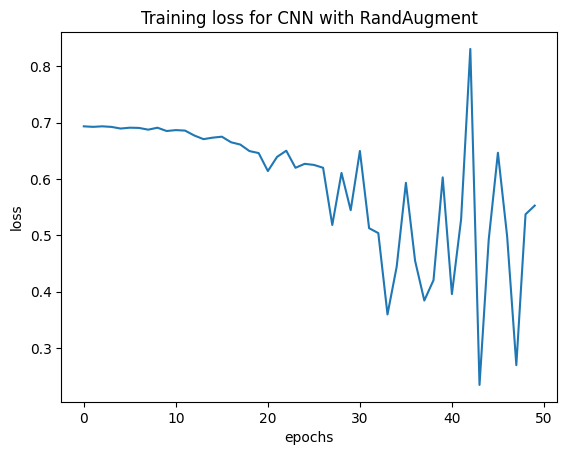

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_val)
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Training loss for CNN with RandAugment');
plt.savefig('CNN_Model_Loss.png')

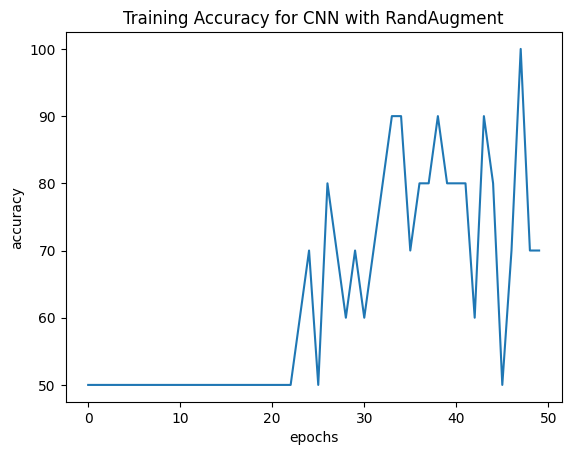

In [ ]:
import matplotlib.pyplot as plt

plt.plot(accs_val)
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('Training Accuracy for CNN with RandAugment');
plt.savefig('CNN_Model_Accuracy.png')

## Fine Tuned Model CNN Model


In [ ]:
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [ ]:
from medmnist import PneumoniaMNIST
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = PneumoniaMNIST(split='train', transform=transform, download=True)
val_data   = PneumoniaMNIST(split='val', transform=transform, download=True)
test_data  = PneumoniaMNIST(split='test', transform=transform, download=True)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=64, shuffle=False)


In [ ]:
## handling imbalance data
labels = torch.tensor(train_data.labels)
pos = labels.sum()
neg = len(labels) - pos

pos_weight = neg / pos
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))


In [ ]:
model = PneumoniaCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


### Training + Validation with Accuracy & Precision

In [ ]:
from sklearn.metrics import precision_score, confusion_matrix

def train_epoch(loader):
    model.train()
    total_loss, y_true, y_pred = 0, [], []

    for x, y in loader:
        x, y = x.to(device), y.float().squeeze().to(device)

        optimizer.zero_grad()
        logits = model(x).squeeze()
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).cpu()
        y_true.extend(y.cpu())
        y_pred.extend(preds)

    acc = (torch.tensor(y_true) == torch.tensor(y_pred)).float().mean()
    prec = precision_score(y_true, y_pred)
    return total_loss / len(loader), acc.item(), prec


def eval_epoch(loader):
    model.eval()
    total_loss, y_true, y_pred = 0, [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.float().squeeze().to(device)
            logits = model(x).squeeze()
            loss = criterion(logits, y)

            total_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).cpu()
            y_true.extend(y.cpu())
            y_pred.extend(preds)

    acc = (torch.tensor(y_true) == torch.tensor(y_pred)).float().mean()
    prec = precision_score(y_true, y_pred)
    return total_loss / len(loader), acc.item(), prec

In [ ]:
EPOCHS = 15
history = {'loss':[], 'val_loss':[], 'acc':[], 'val_acc':[], 'prec':[], 'val_prec':[]}

for epoch in range(EPOCHS):
    tl, ta, tp = train_epoch(train_loader)
    vl, va, vp = eval_epoch(val_loader)

    history['loss'].append(tl)
    history['val_loss'].append(vl)
    history['acc'].append(ta)
    history['val_acc'].append(va)
    history['prec'].append(tp)
    history['val_prec'].append(vp)

    print(f"Epoch {epoch+1}: "
          f"Loss={tl:.4f}, Acc={ta:.4f}, Prec={tp:.4f} | "
          f"Val Acc={va:.4f}")

Epoch 1: Loss=0.2333, Acc=0.7334, Prec=0.9746 | Val Acc=0.8740
Epoch 2: Loss=0.1595, Acc=0.8549, Prec=0.9865 | Val Acc=0.9008
Epoch 3: Loss=0.1375, Acc=0.8845, Prec=0.9842 | Val Acc=0.9218
Epoch 4: Loss=0.1231, Acc=0.9048, Prec=0.9829 | Val Acc=0.8931
Epoch 5: Loss=0.1129, Acc=0.9110, Prec=0.9839 | Val Acc=0.9351
Epoch 6: Loss=0.1043, Acc=0.9235, Prec=0.9825 | Val Acc=0.9408
Epoch 7: Loss=0.0959, Acc=0.9280, Prec=0.9840 | Val Acc=0.9198
Epoch 8: Loss=0.0921, Acc=0.9356, Prec=0.9842 | Val Acc=0.9427
Epoch 9: Loss=0.0872, Acc=0.9382, Prec=0.9843 | Val Acc=0.9580
Epoch 10: Loss=0.0826, Acc=0.9393, Prec=0.9843 | Val Acc=0.9580
Epoch 11: Loss=0.0828, Acc=0.9407, Prec=0.9823 | Val Acc=0.9561
Epoch 12: Loss=0.0778, Acc=0.9458, Prec=0.9862 | Val Acc=0.9580
Epoch 13: Loss=0.0732, Acc=0.9467, Prec=0.9853 | Val Acc=0.9542
Epoch 14: Loss=0.0727, Acc=0.9467, Prec=0.9856 | Val Acc=0.7863
Epoch 15: Loss=0.0673, Acc=0.9494, Prec=0.9845 | Val Acc=0.9294


### Performance Visualization

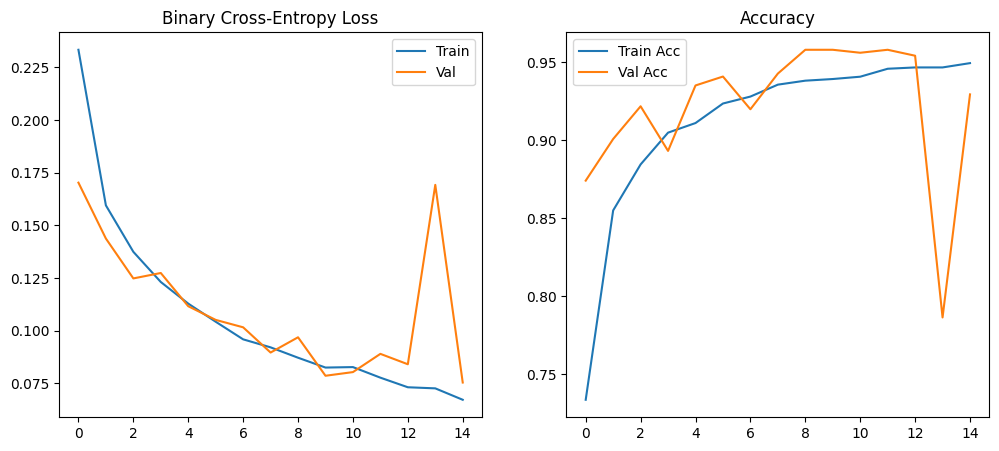

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history['loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.title("Binary Cross-Entropy Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history['acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.show()


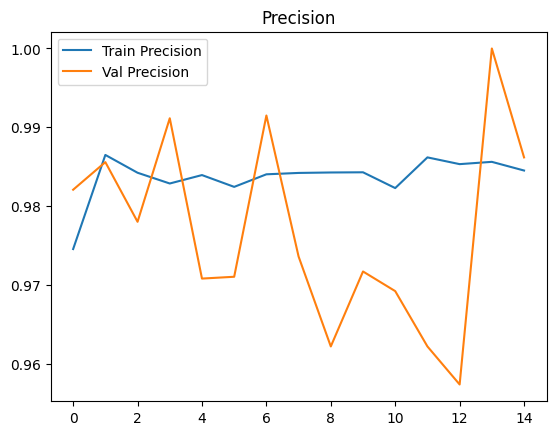

In [ ]:
plt.plot(history['prec'], label='Train Precision')
plt.plot(history['val_prec'], label='Val Precision')
plt.title("Precision")
plt.legend()
plt.show()


In [ ]:
y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = (torch.sigmoid(model(x).squeeze()) > 0.5).cpu()
        y_true.extend(y)
        y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)
print(cm)


[[179  55]
 [ 21 369]]


## Medical Report Generation

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
feature_model = model.features

In [ ]:
# Extract embeddings for training images
train_embeddings = []
feature_model.eval() # Set the feature model to evaluation mode
with torch.no_grad(): # Disable gradient calculation
    for x, _ in train_loader:
        x = x.to(device)
        embeddings = feature_model(x).cpu().numpy() # embeddings here are (batch_size, 128, 1, 1)
        train_embeddings.append(embeddings)

train_embeddings = np.concatenate(train_embeddings, axis=0) # This will be (num_samples, 128, 1, 1)
train_embeddings = train_embeddings.reshape(train_embeddings.shape[0], -1) # Reshape to (num_samples, 128)
train_embeddings = train_embeddings / np.linalg.norm(
    train_embeddings, axis=1, keepdims=True
)

In [ ]:
def generate_medical_report(pred_class, confidence):
    if pred_class == 1:
        report = f"""
        MEDICAL REPORT
        -------------------------
        Findings:
        Chest X-ray shows abnormal opacities in lung regions.

        Impression:
        Findings are suggestive of Pneumonia.

        Model Confidence:
        {confidence:.2f}

        Recommendation:
        Immediate clinical correlation and radiologist review advised.
        """
    else:
        report = f"""
        MEDICAL REPORT
        -------------------------
        Findings:
        Lung fields appear clear with no visible consolidation.

        Impression:
        No radiographic evidence of Pneumonia.

        Model Confidence:
        {confidence:.2f}

        Recommendation:
        Routine follow-up if symptoms persist.
        """
    return report

In [ ]:
def retrieve_similar_images(query_img, top_k=5):
    # Extract query embedding
    query_emb = feature_model.predict(query_img[np.newaxis, ...])
    query_emb = query_emb / np.linalg.norm(query_emb)

    # Compute cosine similarity
    similarity_scores = cosine_similarity(query_emb, train_embeddings)[0]

    # Get top-k similar images
    top_indices = np.argsort(similarity_scores)[-top_k:][::-1]
    return top_indices

In [ ]:
def show_retrieval_results(query_img, retrieved_indices):
    plt.figure(figsize=(15, 4))

    # Show query image
    plt.subplot(1, len(retrieved_indices) + 1, 1)
    plt.imshow(query_img.squeeze(), cmap='gray')
    plt.title("Query Image")
    plt.axis('off')

    # Show retrieved images
    for i, idx in enumerate(retrieved_indices):
        plt.subplot(1, len(retrieved_indices) + 1, i + 2)
        plt.imshow(X_train[idx].squeeze(), cmap='gray')
        plt.title(f"Similar {i+1}")
        plt.axis('off')

    plt.show()

In [ ]:
def full_medical_ai_pipeline(test_index=0, top_k=5):

    # Load test image
    image = X_test[test_index]

    # Predict class
    prediction = model.predict(image[np.newaxis, ...])
    pred_class = np.argmax(prediction)
    confidence = np.max(prediction)

    # Generate report
    report = generate_medical_report(pred_class, confidence)

    # Retrieve similar images
    retrieved_indices = retrieve_similar_images(image, top_k)

    # Display outputs
    print(report)
    show_retrieval_results(image, retrieved_indices)

In [ ]:
# Recompute train_embeddings using DenseNet's features

current_feature_model = model.model.features # Get DenseNet's feature extractor
current_feature_model.eval() # Set to evaluation mode

new_train_embeddings = []
with torch.no_grad():
    for x, _ in train_loader:
        x = x.to(device)
        # Upscale images if they aren't already 224x224 and transform them
        # Note: train_loader should already be configured with the correct transforms (resize to 224x224, grayscale to 3ch, normalize)
        embeddings = current_feature_model(x).cpu().numpy()
        new_train_embeddings.append(embeddings)

new_train_embeddings = np.concatenate(new_train_embeddings, axis=0)
new_train_embeddings = new_train_embeddings.reshape(new_train_embeddings.shape[0], -1) # Flatten to (num_samples, 1024 * 7 * 7)
new_train_embeddings = new_train_embeddings / np.linalg.norm(
    new_train_embeddings, axis=1, keepdims=True
)

# Overwrite the old train_embeddings
train_embeddings = new_train_embeddings

print(f"Recomputed train_embeddings shape: {train_embeddings.shape}")

Recomputed train_embeddings shape: (4708, 50176)


In [ ]:
!pip install opencv-python

In [ ]:
import cv2
import numpy as np

def upscale_image(img, size=224):
    """
    Upscale low-res X-ray images using bicubic interpolation
    """
    img = img.squeeze()
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_CUBIC)
    img = np.clip(img, 0, 1)
    return img

In [ ]:
def generate_gradcam(img, model, last_conv_layer):
    img_batch = img[np.newaxis, ...]

    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_batch)
        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]

    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    return heatmap

In [ ]:
def save_gradcam_image(img, heatmap, filename):
    img = upscale_image(img, 224)
    img_uint8 = np.uint8(255 * img)

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(
        cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2BGR),
        0.6,
        heatmap,
        0.4,
        0
    )

    cv2.imwrite(filename, overlay)

In [ ]:
def save_retrieval_images(query_img, retrieved_idx):
    query_path = "query_image.png"
    cv2.imwrite(query_path, np.uint8(255 * upscale_image(query_img)))

    retrieved_paths = []
    for i, idx in enumerate(retrieved_idx):
        path = f"retrieved_{i+1}.png"
        cv2.imwrite(path, np.uint8(255 * upscale_image(X_train[idx])))
        retrieved_paths.append(path)

    return query_path, retrieved_paths

In [ ]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 31.0 MB/s eta 0:00:00


In [ ]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import A4

def generate_complete_pdf(
    filename,
    diagnosis,
    confidence,
    query_img_path,
    gradcam_img_path, # This can now be None
    retrieved_img_paths
):
    styles = getSampleStyleSheet()
    doc = SimpleDocTemplate(filename, pagesize=A4)
    elements = []

    elements.append(Paragraph("<b>Automated Chest X-ray Medical Report</b>", styles["Title"]))
    elements.append(Spacer(1, 12))

    elements.append(Paragraph(f"<b>Diagnosis:</b> {diagnosis}", styles["Normal"]))
    elements.append(Paragraph(f"<b>Model Confidence:</b> {confidence:.2f}", styles["Normal"]))
    elements.append(Spacer(1, 12))

    elements.append(Paragraph("<b>Query Chest X-ray</b>", styles["Heading2"]))
    elements.append(Image(query_img_path, width=200, height=200))
    elements.append(Spacer(1, 12))

    if gradcam_img_path: # Only add Grad-CAM if path is provided
        elements.append(Paragraph("<b>Grad-CAM Visualization</b>", styles["Heading2"]))
        elements.append(Image(gradcam_img_path, width=200, height=200))
        elements.append(Spacer(1, 12))

    elements.append(Paragraph("<b>Semantically Similar Images</b>", styles["Heading2"]))
    for path in retrieved_img_paths:
        elements.append(Image(path, width=120, height=120))
        elements.append(Spacer(1, 6))

    elements.append(Spacer(1, 12))
    elements.append(Paragraph(
        "<b>Clinical Recommendation:</b> "
        "Radiologist verification and clinical correlation advised.",
        styles["Normal"]
    ))

    doc.build(elements)

In [ ]:
def run_full_clear_pipeline(
    keras_model,        # ✅ real tf.keras.Model
    feature_model,      # embedding model
    test_index=10,
    top_k=5
):

    img = X_test[test_index]

    # --- Prediction ---
    preds = keras_model.predict(img[np.newaxis, ...])
    cls = np.argmax(preds)
    conf = np.max(preds)

    diagnosis = "Pneumonia Detected" if cls == 1 else "Normal Chest X-ray"

    # --- Grad-CAM ---
    heatmap = generate_gradcam(
        img,
        keras_model,
        last_conv_layer="conv5_block16_concat"
    )

    gradcam_path = "gradcam.png"
    save_gradcam_image(img, heatmap, gradcam_path)

    # --- Retrieval ---
    retrieved = retrieve_similar_images(img, top_k)
    query_path, retrieved_paths = save_retrieval_images(img, retrieved)

    # --- PDF ---
    pdf_name = "Final_Medical_Report.pdf"
    generate_complete_pdf(
        pdf_name,
        diagnosis,
        conf,
        query_path,
        gradcam_path,
        retrieved_paths
    )

    print("✅ Clear medical report generated:", pdf_name)


        MEDICAL REPORT
        -------------------------
        Findings:
        Chest X-ray shows abnormal opacities in lung regions.

        Impression:
        Findings are suggestive of Pneumonia.

        Model Confidence:
        1.00

        Recommendation:
        Immediate clinical correlation and radiologist review advised.
        


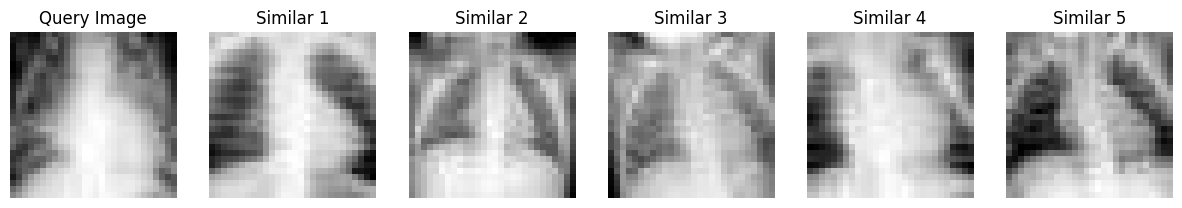

In [ ]:
full_medical_ai_pipeline(test_index=10, top_k=5)

## Densenet Model implementation

In [ ]:
class DenseNetPneumonia(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.densenet121(weights="IMAGENET1K_V1")

        # Freeze feature extractor
        for param in self.backbone.features.parameters():
            param.requires_grad = False

        # Replace classifier head
        self.backbone.classifier = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.backbone(x)


In [ ]:
data_flag = 'pneumoniamnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)), # Resize images to 224x224 for DenseNet
    transforms.RandAugment(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)), # Resize images to 224x224 for DenseNet
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

train_dataset = DataClass(split='train', transform=train_transform, download=True)
val_dataset   = DataClass(split='val', transform=val_transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

In [ ]:
def train_epoch(model, loader, optimizer):
    model.train()
    running_loss, correct = 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.float().to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = F.binary_cross_entropy_with_logits(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5)
        correct += (preds == y.bool()).sum().item()

    return running_loss / len(loader), 100 * correct / len(loader.dataset)


In [ ]:
@torch.no_grad()
def validate(model, loader):
    model.eval()
    running_loss, correct = 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.float().to(device)
        logits = model(x)
        loss = F.binary_cross_entropy_with_logits(logits, y)

        running_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5)
        correct += (preds == y.bool()).sum().item()

    return running_loss / len(loader), 100 * correct / len(loader.dataset)


In [ ]:
scaler = torch.cuda.amp.GradScaler()


/tmp/ipython-input-2655216266.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(


In [ ]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device).float().squeeze()

        optimizer.zero_grad()

        # Removed autocast and scaler operations as CUDA is not available.
        logits = model(x).squeeze()
        #print(f"Logits requires_grad: {logits.requires_grad}") # Diagnostic line
        loss = criterion(logits, y)
        #print(f"Loss requires_grad: {loss.requires_grad}") # Diagnostic line

        loss.backward() # Directly call backward on the loss
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5)
        correct += (preds == y.bool()).sum().item()
        total += y.size(0)

    acc = 100 * correct / total
    return total_loss / len(loader), acc

In [ ]:
def validate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device).float().squeeze()
            logits = model(x).squeeze()
            loss = criterion(logits, y)

            total_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5)
            correct += (preds == y.bool()).sum().item()
            total += y.size(0)

    acc = 100 * correct / total
    return total_loss / len(loader), acc

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )
        pt = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()

In [ ]:
def train_epoch(model, loader):
    model.train()
    correct, total_loss = 0, 0

    for x, y in loader:
        x = x.to(device)
        y = y.float().to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5)
        correct += (preds == y.bool()).sum().item()

    return total_loss / len(loader), 100 * correct / len(loader.dataset)

In [ ]:
model = DenseNetPneumonia().to(device)
criterion = FocalLoss().to(device)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=20
)

epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    # Ensure the latest train_epoch and validate definitions from uWXg8RO3fi51 and WAWtE7olfmaM are active.
    # These functions are designed to use `optimizer` and `criterion` as globals.
    tl, ta = train_epoch(model, train_loader)
    vl, va = validate(model, val_loader)

    train_losses.append(tl)
    val_losses.append(vl)
    train_accs.append(ta)
    val_accs.append(va)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Acc: {ta:.2f}% | Val Acc: {va:.2f}%")

Epoch 01 | Train Acc: 78.63% | Val Acc: 88.36%
Epoch 02 | Train Acc: 84.66% | Val Acc: 90.08%
Epoch 03 | Train Acc: 85.45% | Val Acc: 90.65%
Epoch 04 | Train Acc: 87.28% | Val Acc: 90.84%
Epoch 05 | Train Acc: 86.34% | Val Acc: 91.98%
Epoch 06 | Train Acc: 86.98% | Val Acc: 91.03%
Epoch 07 | Train Acc: 87.55% | Val Acc: 91.79%
Epoch 08 | Train Acc: 88.83% | Val Acc: 91.79%
Epoch 09 | Train Acc: 88.38% | Val Acc: 92.18%
Epoch 10 | Train Acc: 87.91% | Val Acc: 91.79%


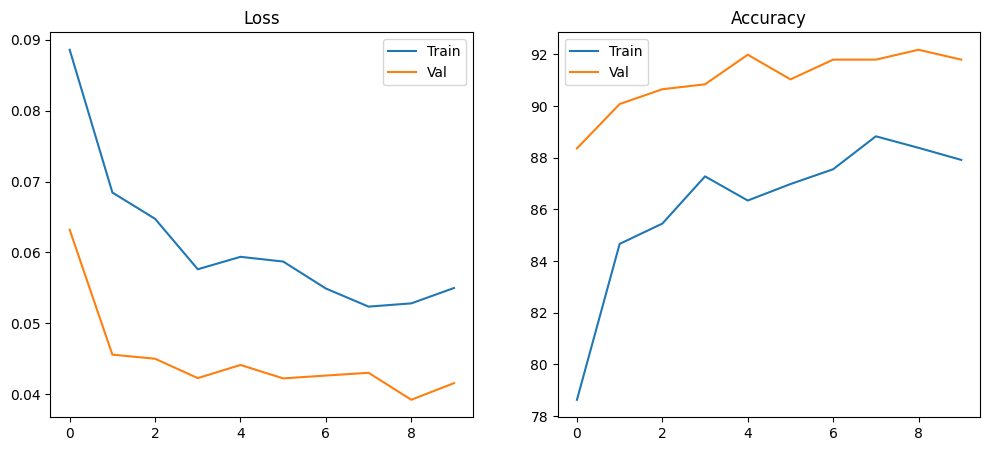

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Val")
plt.title("Accuracy")
plt.legend()

plt.show()

In [ ]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
class DenseNetPneumonia(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = models.densenet121(weights="IMAGENET1K_V1")

        # Freeze everything
        for param in self.model.parameters():
            param.requires_grad = False

        # 🔥 Unfreeze last dense block
        for param in self.model.features.denseblock4.parameters():
            param.requires_grad = True

        # New classifier
        self.model.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        return self.model(x)


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )
        pt = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()


## Optimizer + Cosine Scheduler

In [ ]:
model = DenseNetPneumonia().to(device)

# --- Diagnostic line to check trainable parameters ---
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_trainable_params}")
# -----------------------------------------------------

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=20
)

Number of trainable parameters: 2684417


In [ ]:
def train_epoch(model, loader):
    model.train()
    correct, total_loss = 0, 0

    for x, y in loader:
        x = x.to(device)
        y = y.float().to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5)
        correct += (preds == y.bool()).sum().item()

    return total_loss / len(loader), 100 * correct / len(loader.dataset)

In [ ]:
@torch.no_grad()
def validate(model, loader):
    model.eval()
    correct, total_loss = 0, 0

    for x, y in loader:
        x = x.to(device)
        y = y.float().to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5)
        correct += (preds == y.bool()).sum().item()

    return total_loss / len(loader), 100 * correct / len(loader.dataset)